In [99]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits

import healpy as hp

In [100]:
data = fits.open("table1.dat")
data.info()

Filename: table1.dat
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     118   ()      
  1  table1.dat    1 TableHDU       188   487R x 27C   [I4, A1, I1, I1, F4.1, F4.3, F5.1, I2, I2, F4.1, F4.1, A1, I2, I2, I2, I3, F5.2, F4.2, I2, I2, A2, I2, I1, A2, I3, I3, F4.2]   


In [101]:
abell_cat = data[1].data

In [102]:
data[1].columns

ColDefs(
    name = 'Abell'; format = 'I4'; disp = 'I4'; start = 1
    name = 'Note'; format = 'A1'; start = 5
    name = 'Rich'; format = 'I1'; disp = 'I1'; start = 7
    name = 'Dist'; format = 'I1'; disp = 'I1'; start = 9
    name = 'm10'; format = 'F4.1'; unit = 'mag'; disp = 'F4.1'; start = 11
    name = 'z'; format = 'F4.3'; disp = 'F4.3'; start = 16
    name = 'Radius'; format = 'F5.1'; unit = 'arcmin'; disp = 'F5.1'; start = 21
    name = 'RAh'; format = 'I2'; unit = 'h'; disp = 'I2'; start = 27
    name = 'RAm'; format = 'I2'; unit = 'min'; disp = 'I2'; start = 29
    name = 'RAs'; format = 'F4.1'; unit = 's'; disp = 'F4.1'; start = 31
    name = 'e_RAs'; format = 'F4.1'; unit = 's'; disp = 'F4.1'; start = 36
    name = 'DE-'; format = 'A1'; start = 41
    name = 'DEd'; format = 'I2'; unit = 'deg'; disp = 'I2'; start = 42
    name = 'DEm'; format = 'I2'; unit = 'arcmin'; disp = 'I2'; start = 44
    name = 'DEs'; format = 'I2'; unit = 'arcsec'; disp = 'I2'; start = 46
    name 

In [103]:
abell_cat = abell_cat[abell_cat["Rich"] > 0]

In [104]:
nside=128
npix = hp.nside2npix(nside)
map = np.zeros(npix)

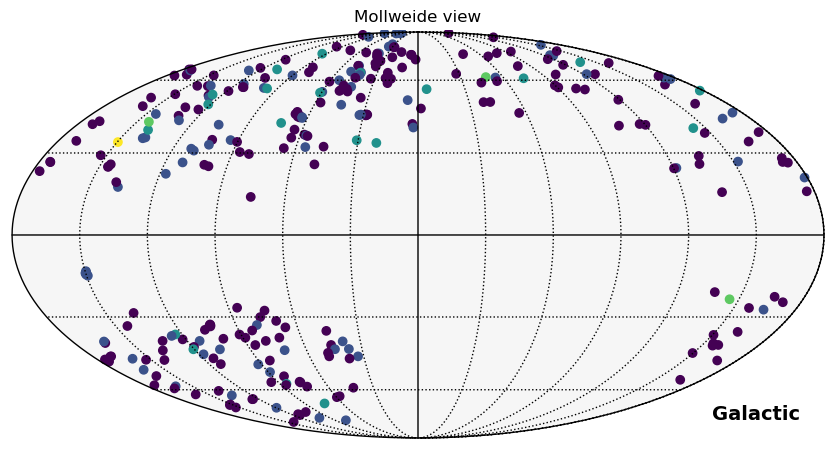

In [105]:
from astropy.coordinates import SkyCoord

coords = [SkyCoord(ra=f'{ac["Rah"]}h{ac["RAm"]}m{ac["RAs"]}s',
                   dec=f'{ac["DE-"]}{ac["DEd"]}d{ac["DEm"]}m{ac["DEs"]}s',
                   frame='icrs') for ac in abell_cat]

abell_cat_ra = np.array([c.ra.rad for c in coords])
abell_cat_dec = np.array([c.dec.rad for c in coords])

hp.mollview(map, cmap='RdBu', min=-1, max=1, cbar=False, coord='G')
hp.projscatter(np.pi/2 - abell_cat_dec, abell_cat_ra, c=abell_cat["Rich"], coord='C')
hp.graticule()